# **Notebook 1: Pre-procesamiento**
### Introducción a la Ciencia de Datos 
*Alumno: Norman O. Guzmán Chaboya*

Este cuaderno utiliza el dataset *Breast Cancer Wisconsin (Original)* del repositorio UCI, con 699 muestras descritas por 9 atributos citológicos (escala ordinal de 1 a 10) y una clase diagnóstico: benigno o maligno.

**Objetivos:**
1. Realizar un análisis exploratorio de datos (EDA).
2. Aplicar al menos dos técnicas de preprocesamiento de los siguientes tipos de procesamiento:
    - Limpieza de datos
    - Aumento de datos
    - Extracción de características
    - Reducción de dimensionalidad

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('bmh')
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

Importamos el *dataset* y desplegamos una vista previa para visualizar de manera global el contenido de este:

In [2]:
data = pd.read_csv('./breast-cancer-wisconsin.data', header=None)

In [3]:
data_cols = column_names = [
    "sample_id", "clump_thickness", "cell_size_uniformity",
    "cell_shape_uniformity", "marginal_adhesion", "sgl_epithelial_cell_size",
    "bare_nuclei", "bland_chromatin", "normal_nucleoli", "mitoses", "class"
]
data.columns = data_cols
data.head(600)

,sample_id,clump_thickness,cell_size_uniformity,cell_shape_uniformity,marginal_adhesion,sgl_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
595,1320141,5,1,1,1,2,1,2,1,1,2
596,1325309,4,1,2,1,2,1,2,1,1,2
597,1333063,5,1,3,1,2,1,3,1,1,2
598,1333495,3,1,1,1,2,1,2,1,1,2


### Exploración

In [4]:
data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
sample_id,699.0,1071704.10,617095.73,61634.0,870688.5,1171710.0,1238298.0,13454352.0
clump_thickness,699.0,4.42,2.82,1.0,2.0,4.0,6.0,10.0
cell_size_uniformity,699.0,3.13,3.05,1.0,1.0,1.0,5.0,10.0
cell_shape_uniformity,699.0,3.21,2.97,1.0,1.0,1.0,5.0,10.0
marginal_adhesion,699.0,2.81,2.86,1.0,1.0,1.0,4.0,10.0
sgl_epithelial_cell_size,699.0,3.22,2.21,1.0,2.0,2.0,4.0,10.0
bland_chromatin,699.0,3.44,2.44,1.0,2.0,3.0,5.0,10.0
normal_nucleoli,699.0,2.87,3.05,1.0,1.0,1.0,4.0,10.0
mitoses,699.0,1.59,1.72,1.0,1.0,1.0,1.0,10.0
class,699.0,2.69,0.95,2.0,2.0,2.0,4.0,4.0


Al ver los estimadores de las características mapeadas en el conjunto de datos, es notable que los primeros 3 cuartiles repersenten valores bajos, apuntando a que los casos dónde se tiene un tumor maligno representan una minoría. Tal y cómo se describe en la hoja técnica del *dataset*, los datos van de 1 a 10, con excepción de la marca de clase, que es 2 o 4, pacientes con tumores benignos o malignos. 

De la misma manera, la hoja técnica y el conjunto en sí coincide con la representación de los datos faltantes, aunque observando la suma por columna, nos percatamos de que únicamente se tienen faltantes en la columna `bare_nulcei`: 

In [5]:
col_error = (data == '?').sum()
print(col_error)

sample_id                    0
clump_thickness              0
cell_size_uniformity         0
cell_shape_uniformity        0
marginal_adhesion            0
sgl_epithelial_cell_size     0
bare_nuclei                 16
bland_chromatin              0
normal_nucleoli              0
mitoses                      0
class                        0
dtype: int64


In [6]:
data_non = data.copy()

data_non = data_non.replace('?', np.nan)

cols_data = [
    "clump_thickness", "cell_size_uniformity",
    "cell_shape_uniformity", "marginal_adhesion", "sgl_epithelial_cell_size",
    "bare_nuclei", "bland_chromatin", "normal_nucleoli", "mitoses", "class"
]

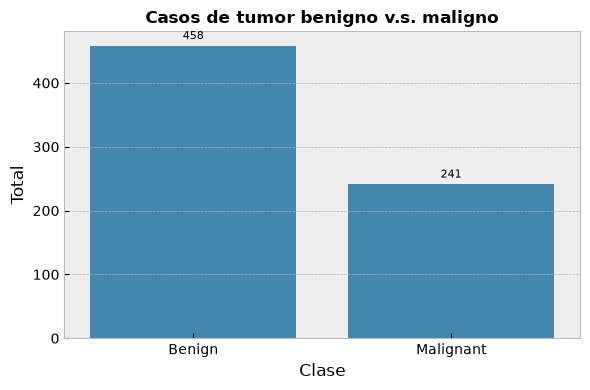

In [7]:
class_map = {2: 'Benign', 4: 'Malignant'}
tumor_class = data_non['class'].map(class_map)

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=tumor_class)

plt.title('Casos de tumor benigno v.s. maligno', fontsize=12, fontweight='bold')
plt.xlabel('Clase')
plt.ylabel('Total')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 3), 
                textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

Al graficar el histograma de la distribución por clase, observamos que existe un debalance considerable a favor de los casos de tumores benignos, lo que puede representar un reto al momento de modelar los datos aquí representados. El desbalance puede llevar a un probelma de *over-fitting* ya que tenemos una clase minoritaria que podría ser una representación muy pobre de realidad y que la represente con certeza. Será necesario aplicar algún método de imputación para sortear el problema. 

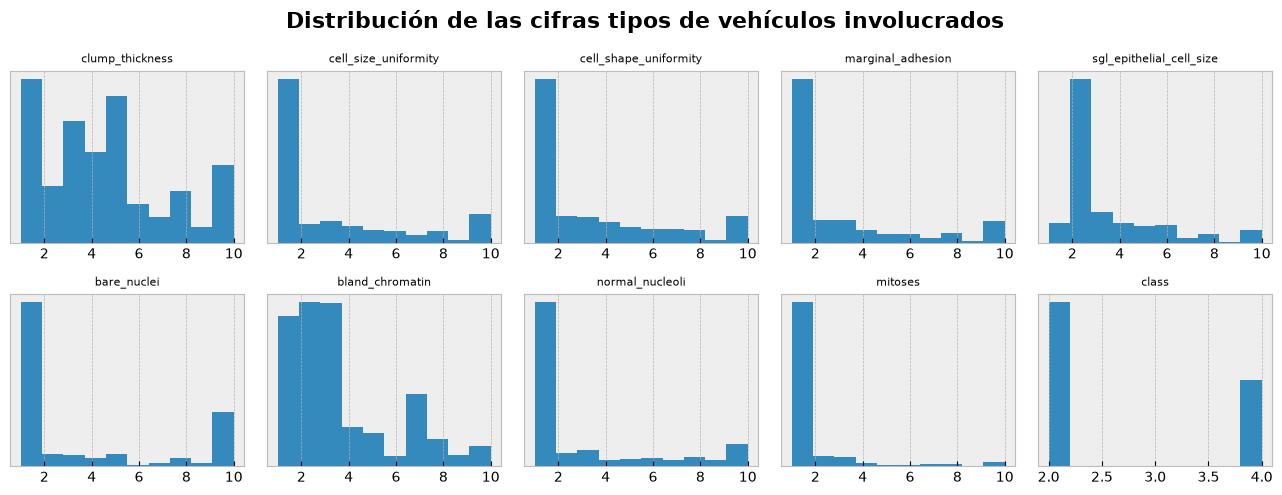

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))

with plt.style.context('bmh'):
    for ax, col in zip(axes.ravel(), cols_data):
        ax.hist(data_non[col].astype(float), bins=10)
        ax.set_title(col, fontsize=8)
        ax.set_yticks([])
    
    fig.suptitle("Distribución de características",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

Cómo ya se mencionaba al momento de observar los estimadores globales, existe una cola muy larga hacia la derecha de las distirbuciones de la mayoría de características, lo que significa que los valores tienden a ser muy bajos en la mayoría de instancias registrads. Sin embargo, `clump_thickness` rompe esta regla, presentando una distribución un *poco* más uniforme que sus contrapartes, lo que se traduce en que la clase dominante no sobresale del todo sobre la otra. 

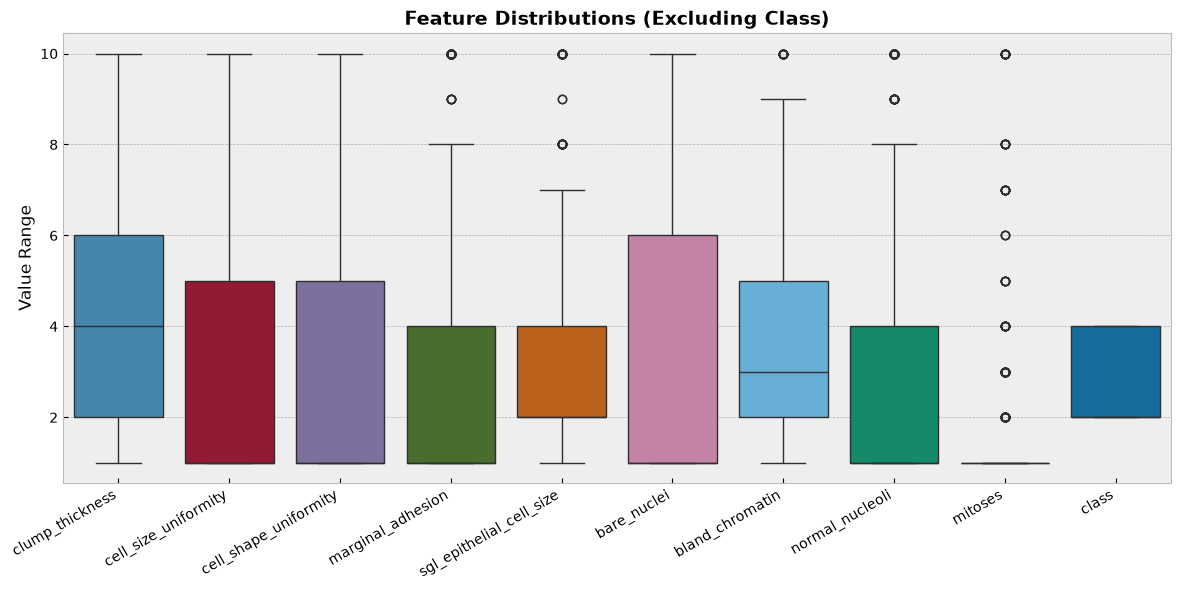

In [9]:
plt.figure(figsize=(12, 6))

with plt.style.context('bmh'):
    sns.boxplot(
        data=data_non[cols_data].astype(float),
    )
    plt.title("Boxplot de características", fontsize=14, fontweight="bold")
    plt.ylabel("Rango")
    plt.xticks(rotation=30, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

Los *boxplots* de las distribuciones confirman lo ya discutido sonbre la cola hacia la derecha, y dejan en claro que la mayoría de características tienden a valores pequeños. Sin embargo, algo muy notable es el hecho de que `mitoses` se concentra mayormente en un valor igual a 1, y que tiene contados datos atípicos que superan esa cifra.

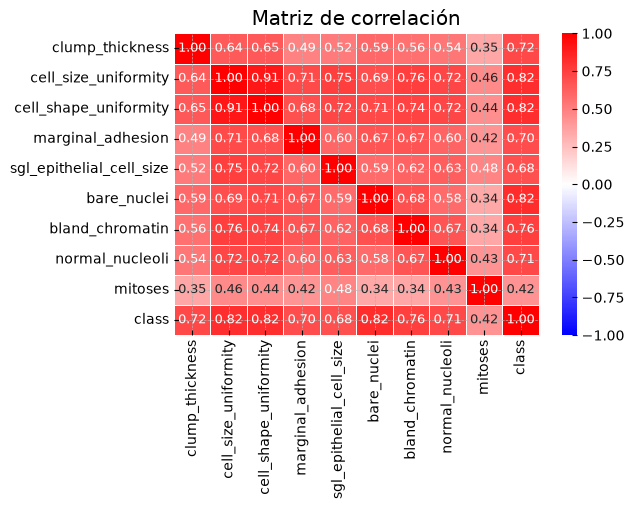

In [10]:
corr = data_non[
    cols_data
].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.2))

sns.heatmap(corr, cmap="bwr", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.6, linecolor="white", ax=ax)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

Este mapa de calor muestra la correlación entre los 9 atributos y la clase diagnóstica, y todas las relaciones son positivas: valores más altos en cualquier atributo se asocian con mayor probabilidad de malignidad. La correlación más alta de toda la matriz es la de `cell_size_uniformity` y `cell_shape_uniformity` (0.91), lo que indica que miden aspectos muy parecidos y aportan casi la misma información. Esa redundancia puede causar multicolinealidad en modelos lineales y justifica aplicar PCA o conservar solo una de las dos. Ambas, junto con `bare_nuclei`, son además las más asociadas como predictoras de la clase. En contraste, `mitoses` es la variable menos significativa: su correlación con la clase es la más baja (0.42) y también es débil con el resto de atributos.

### Limpieza

Iniciamos la limpieza verificando si existen registros duplicados. Puesto que `sample_id` identifica a cada muestra, lo tomamos como clave y listamos todos los registros que comparten un mismo identificador (`keep=False`), ordenados por este, para revisar algunos ejemplos:

In [11]:
duplicados = data[data.duplicated(subset=['sample_id'], keep=False)]
duplicados.sort_values("sample_id").head(6)

,sample_id,clump_thickness,cell_size_uniformity,cell_shape_uniformity,marginal_adhesion,sgl_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
267,320675,3,3,5,2,3,10,7,1,1,4
272,320675,3,3,5,2,3,10,7,1,1,4
269,385103,1,1,1,1,2,1,3,1,1,2
575,385103,5,1,2,1,2,1,3,1,1,2
607,411453,1,1,1,1,2,1,1,1,1,2
271,411453,5,1,1,1,2,1,3,1,1,2


Eliminamos los registros con `sample_id` repetido, conservando únicamente la primera aparición de cada uno, y desplegamos el nuevo total de registros:

In [12]:
data = data.drop_duplicates(subset=["sample_id"], keep='first')
print(f"Total de registros tras limpieza: {len(data)}")

Total de registros tras limpieza: 645


Una vez removidos los duplicados, el identificador deja de ser útil, pues no aporta información sobre el diagnóstico, por lo que lo descartamos de la tabla:

In [13]:
data = data.drop(columns='sample_id')

#### Validación de tipos

Verificamos el tipo de dato de cada atributo. Se espera que todos sean numéricos, aunque, como se mencionó durante la exploración, los faltantes de `bare_nuclei` están marcados con `?`, lo que impide que la columna se interprete como entera:

In [14]:
data.dtypes

clump_thickness             int64
cell_size_uniformity        int64
cell_shape_uniformity       int64
marginal_adhesion           int64
sgl_epithelial_cell_size    int64
bare_nuclei                   str
bland_chromatin             int64
normal_nucleoli             int64
mitoses                     int64
class                       int64
dtype: object

Para comprobarlo, observamos un fragmento de la columna `bare_nuclei` en el que aparece uno de estos símbolos:

In [15]:
data.iloc[21:26]["bare_nuclei"]

22    1
23    ?
24    1
25    7
26    1
Name: bare_nuclei, dtype: str

Reemplazamos `?` por `np.nan` y convertimos la columna a `Int64` (entero que admite valores nulos), de modo que los faltantes queden representados correctamente sin perder el tipo entero. El resultado se guarda en un nuevo *dataframe*, `data_coerced` y verificamos la conversión sobre el mismo fragmento de la columna:

In [16]:
data_coerced = data.replace('?', np.nan)
data_coerced['bare_nuclei'] = data_coerced['bare_nuclei'].astype('Int64')

In [17]:
data_coerced.iloc[21:26]["bare_nuclei"]

22       1
23    <NA>
24       1
25       7
26       1
Name: bare_nuclei, dtype: Int64

#### Interpolación (KNN)

Para reemplazar los faltantes utilizamos `KNNImputer` con 5 vecinos y ponderación por distancia, de modo que cada valor faltante se estima a partir de las muestras más cercanas en el resto de atributos. Como la imputación devuelve valores continuos, los redondeamos para regresar `bare_nuclei` a su escala entera original. Finalmente, revisamos que no queden nulos en ninguna columna:

In [19]:
imputer = KNNImputer(n_neighbors=5, weights="distance")
data_imputed = pd.DataFrame(imputer.fit_transform(data_coerced), columns=data_coerced.columns)

data_imputed['bare_nuclei'] = data_imputed['bare_nuclei'].astype(float).round().astype('Int64')

col_error = (data_imputed == np.nan).sum()
print(col_error)

clump_thickness             0
cell_size_uniformity        0
cell_shape_uniformity       0
marginal_adhesion           0
sgl_epithelial_cell_size    0
bare_nuclei                 0
bland_chromatin             0
normal_nucleoli             0
mitoses                     0
class                       0
dtype: Int64


Observamos el mismo fragmento de `bare_nuclei` posterior a la imputación, donde el símbolo `?` ya fue reemplazado por un valor:

In [20]:
data_imputed.iloc[21:26]["bare_nuclei"]

21    1
22    8
23    1
24    7
25    1
Name: bare_nuclei, dtype: Int64

Comparamos gráficamente la distribución de `bare_nuclei` antes y después de la interpolación, superponiendo ambos histogramas:

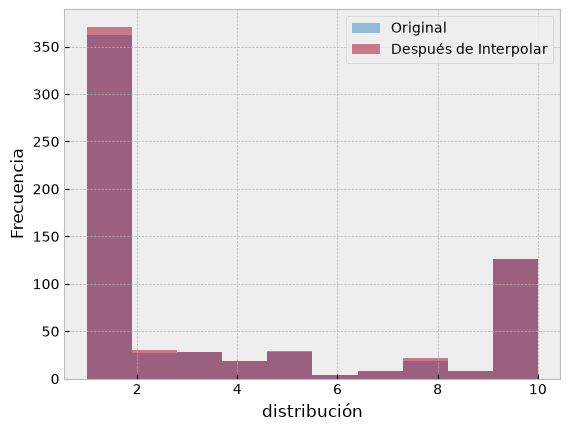

In [21]:
plt.hist(data_coerced["bare_nuclei"], bins=10, alpha=.5, label="Original")
plt.hist(data_imputed["bare_nuclei"], bins=10, alpha=.5, label="Después de Interpolar")

plt.ylabel("Frecuencia"); plt.xlabel("distribución")
plt.legend()

Vemos que no existe mucha intervariabilidad entre la distribución original y los escasos datos que fueron generados por medio de la interpolación por KNN.

### Aumento de Datos

In [22]:
aug_data = data_imputed.copy()

Separamos los datos en entrenamiento (75%) y prueba (25%), estratificando por clase para conservar la proporción entre tumores benignos y malignos. Fijamos una semilla (`ran`) para que los resultados sean reproducibles; el aumento se aplicará únicamente sobre el conjunto de entrenamiento:

In [23]:
ran = 66

X = aug_data.drop(columns=["class"])
y = aug_data["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=ran
)

print("Entrenamiento:", y_train.value_counts().sort_index().to_dict())
print("Prueba:", y_test.value_counts().sort_index().to_dict())

Entrenamiento: {2.0: 309, 4.0: 174}
Prueba: {2.0: 104, 4.0: 58}


#### Ruido Gaussiano 

Primeramente aumentamos los datos añadiendo ruido gaussiano (*jittering*). Estandarizamos el conjunto de entrenamiento con `StandardScaler` y le sumamos ruido con media 0 y desviación estándar de 0.03. También generamos una variante que multiplica cada muestra por un factor aleatorio cercano a 1 (media 1, desviación estándar de 0.03). Comparamos mediante histogramas la distribución original y la del *jittering* para `clump_thickness`:

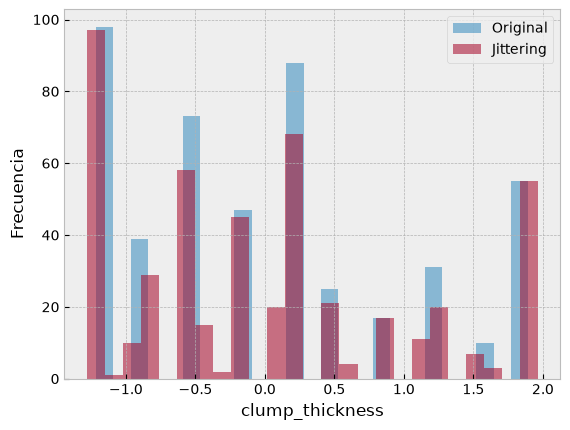

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

rng = np.random.default_rng(ran)
noise = rng.normal(0, 0.03, size=X_scaled.shape)
X_jitter = X_scaled + noise

alpha = rng.normal(1.0, 0.03, size=(len(X_scaled), 1))
X_scaled_aug = X_scaled * alpha

feature = 0
plt.hist(X_scaled[:, feature], bins=25, alpha=.55, label="Original")
plt.hist(X_jitter[:, feature], bins=25, alpha=.55, label="Jittering")
plt.xlabel("clump_thickness"); plt.ylabel("Frecuencia"); plt.legend();

La distribución de los datos sintéticos se asemeja un tanto a la original, pero la diferencia es muy notoria en los cuartiles intermedios; en las colas casi existe un sobrelape entre distribuciones. 

#### SMOTE

Como alternativa implementamos manualmente SMOTE (cortesía del notebook sobre aumento de datos del curso), cuyo objetivo es generar muestras sintéticas de la clase minoritaria. Para cada muestra nueva se elige al azar un ejemplar de esta clase, se selecciona uno de sus `k` vecinos más cercanos y se genera un punto sobre el segmento que los une, interpolando con un factor aleatorio entre 0 y 1:

In [25]:
def manual_smote(X_minority, n_samples, k=5, random_state=42):
    # Genera muestras sintéticas SMOTE a partir de datos numéricos escalados.
    local_rng = np.random.default_rng(random_state)
    k = min(k, len(X_minority) - 1)
    if k < 1:
        raise ValueError("Se necesitan al menos dos muestras minoritarias.")

    model = NearestNeighbors(n_neighbors=k + 1).fit(X_minority)
    all_neighbors = model.kneighbors(X_minority, return_distance=False)[:, 1:]
    synthetic = []

    for _ in range(n_samples):
        i = int(local_rng.integers(len(X_minority)))
        j = int(local_rng.choice(all_neighbors[i]))
        lam = local_rng.uniform(0, 1)
        synthetic.append(X_minority[i] + lam * (X_minority[j] - X_minority[i]))

    return np.asarray(synthetic)


Aplicamos la función sobre el conjunto de entrenamiento estandarizado. Identificamos la clase minoritaria, calculamos cuántas muestras sintéticas se necesitan para igualar a la clase mayoritaria, las generamos y las concatenamos al conjunto de entrenamiento, y verificamos la nueva distribución de clases:

In [26]:
minority_label = y_train.value_counts().idxmin()
minority_mask = y_train.to_numpy() == minority_label

# 2. Ajustar el escalador SOLO con entrenamiento y transformar sus datos.
X_train_scaled = scaler.fit_transform(X_train)
X_min = X_train_scaled[minority_mask]


# Número necesario para igualar la clase mayoritaria.
class_counts = y_train.value_counts()
n_to_generate = int(class_counts.max() - class_counts.min())
X_synthetic = manual_smote(X_min, n_samples=n_to_generate, k=5)

# Conjunto balanceado en escala estandarizada.
X_smote_scaled = np.vstack([X_train_scaled, X_synthetic])
y_smote = np.r_[y_train.to_numpy(), np.full(n_to_generate, minority_label)]

print("Muestras sintéticas generadas:", len(X_synthetic))
print("Distribución después de SMOTE:", pd.Series(y_smote).value_counts().sort_index().to_dict())

Muestras sintéticas generadas: 135
Distribución después de SMOTE: {2.0: 309, 4.0: 309}


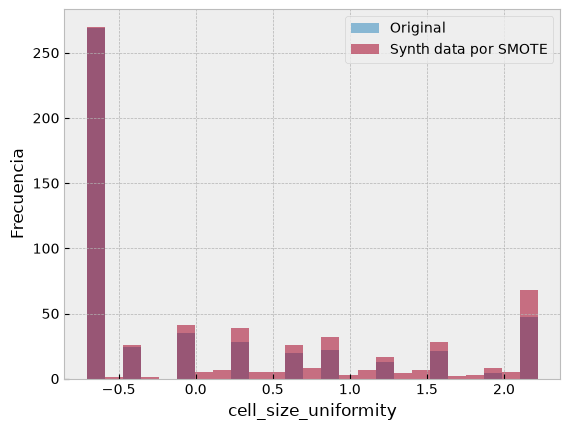

In [27]:
feature = 1 # cell_size_uniformity
plt.hist(X_scaled[:, feature], bins=25, alpha=.55, label="Original")
plt.hist(X_smote_scaled[:, feature], bins=25, alpha=.55, label="Synth data por SMOTE")
plt.xlabel("cell_size_uniformity"); plt.ylabel("Frecuencia"); plt.legend();

Contrario a los datos generados por medio de *jitter*, la nueva distribución conserva un semejanza mayor con la de los datos originales.

Reconstruimos un *dataframe* con los datos aumentados (ya estandarizados) y agregamos de nuevo la columna objetivo `class`:

In [28]:
data_smote = pd.DataFrame(X_smote_scaled, columns=X.columns).copy()

# Agregar la columna objetivo (class)
data_smote["class"] = y_smote

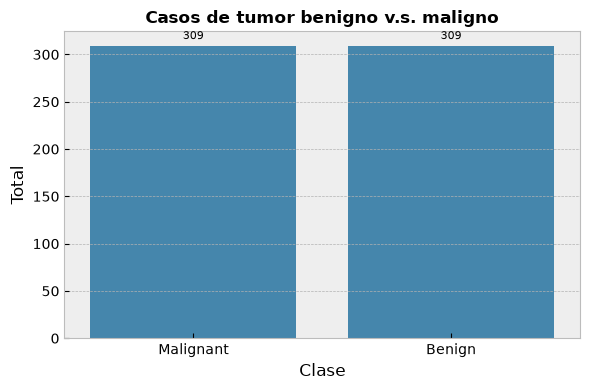

In [29]:
tumor_class = data_smote['class'].map(class_map)

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=tumor_class)

plt.title('Casos de tumor benigno v.s. maligno', fontsize=12, fontweight='bold')
plt.xlabel('Clase')
plt.ylabel('Total')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 3), 
                textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

Graficamos nuevamente el conteo de casos por clase, ahora sobre el conjunto aumentado, para verificar el balance.

### Reducción de dimensionalidad

Para la reducción de dimensionalidad importamos las herramientas necesarias:

In [35]:
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import BoundaryNorm
from sklearn.manifold import TSNE
import umap


Sobre el conjunto aumentado realizamos una nueva partición en entrenamiento (80%) y prueba (20%), estratificada por clase. El conjunto de entrenamiento es el que se utilizará para las proyecciones:

In [31]:
X = data_smote.drop(columns=["class"])
y = data_smote["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=ran
)

print("Entrenamiento:", y_train.value_counts().sort_index().to_dict())
print("Prueba:", y_test.value_counts().sort_index().to_dict())

Entrenamiento: {2.0: 247, 4.0: 247}
Prueba: {2.0: 62, 4.0: 62}


#### t-SNE

Aplicamos t-SNE para proyectar las 9 características a dos dimensiones, con perplejidad de 10, inicialización por PCA y un máximo de 1000 iteraciones. Reportamos la divergencia KL final como medida de qué tan bien la proyección conserva las vecindades de los datos, y graficamos el resultado coloreando cada punto según su clase:

Forma: (494, 2)
KL final: 0.4378


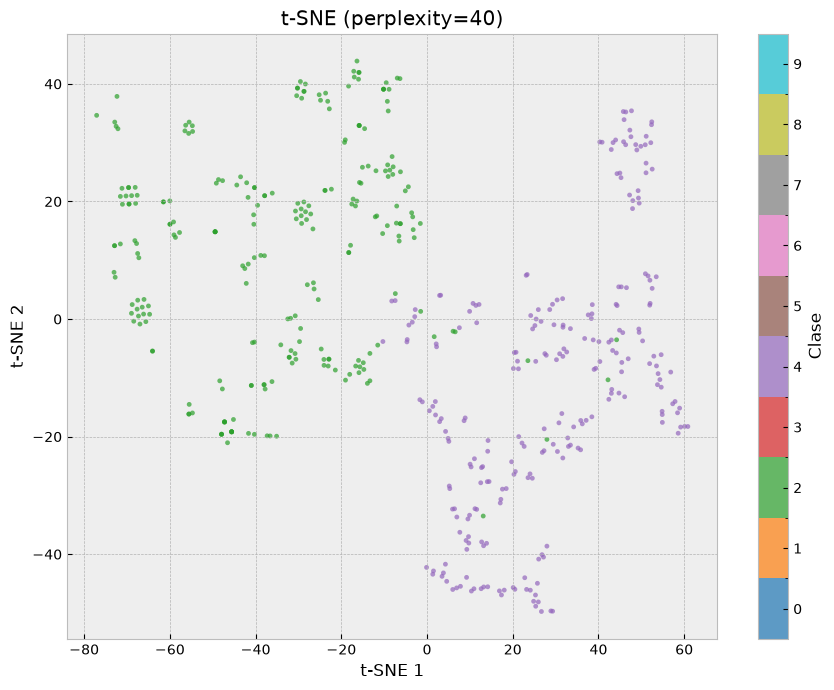

In [45]:
cmap = plt.get_cmap('tab10')
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

tsne = TSNE(n_components=2, perplexity=10, init='pca', learning_rate='auto',
            max_iter=1000, random_state=ran, n_jobs=1)
Z_tsne = tsne.fit_transform(X_train)

print("Forma:", Z_tsne.shape)

print(f'KL final: {tsne.kl_divergence_:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                c=np.asarray(y_train), cmap=cmap, norm=norm,
                s=12, alpha=0.7, linewidths=0)

cbar = fig.colorbar(sc, ax=ax, ticks=np.arange(0, 10))
cbar.set_label("Clase")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE (perplexity=40)")
plt.tight_layout()
plt.show()

#### UMAP

De manera similar, aplicamos UMAP con 2 componentes, 15 vecinos, distancia mínima de 0.1 y métrica euclidiana:

In [40]:
reductor_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                          metric='euclidean', random_state=ran, n_jobs=1)
Z_umap = reductor_umap.fit_transform(X_train)

print("Forma:", Z_umap.shape)

Forma: (494, 2)


Graficamos la proyección obtenida con UMAP, coloreando cada punto según su clase:

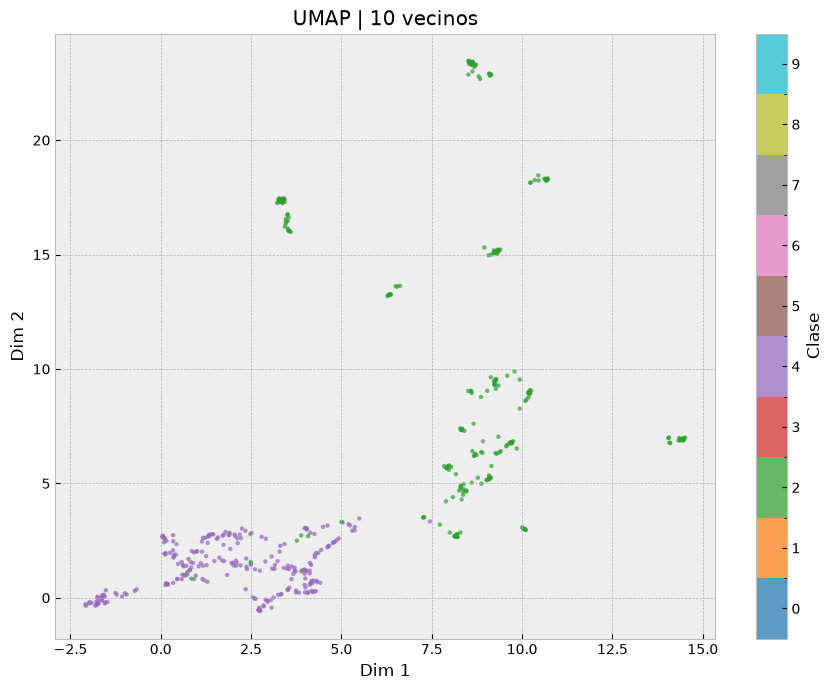

In [44]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(Z_umap[:, 0], Z_umap[:, 1],
                c=np.asarray(y_train), cmap=cmap, norm=norm,
                s=10, alpha=0.7, linewidths=0)

cbar = fig.colorbar(sc, ax=ax, ticks=np.arange(0, 10))
cbar.set_label("Clase")

ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_title(f"UMAP | 10 vecinos")
plt.tight_layout()
plt.show()

### Extracción de Características

Para la extracción de características partimos de una copia del conjunto aumentado, sobre la cual crearemos nuevas variables derivadas de las originales:

In [46]:
data_feat = data_smote.copy()

#### Estimadores globales

Creamos tres variables que resumen el perfil general de cada muestra: `n_high`, el número de atributos con valor mayor o igual a 7; `mean_score`, el promedio de los atributos; y `std_score`, su desviación estándar, que indica qué tan dispersos son los puntajes de una misma muestra:

In [49]:
data_feat['n_high'] = (data_feat[cols_data] >= 7).sum(axis=1)
data_feat['mean_score']  = data_feat[cols_data].mean(axis=1)
data_feat['std_score']   = data_feat[cols_data].std(axis=1)

### Estimadores por Dominio

Creamos `nuclear_mean`, el promedio de los atributos relacionados con el núcleo celular (`bare_nuclei`, `bland_chromatin`, `normal_nucleoli` y `mitoses`):

In [50]:
data_feat['nuclear_mean']   = data_feat[['bare_nuclei','bland_chromatin','normal_nucleoli','mitoses']].mean(axis=1)

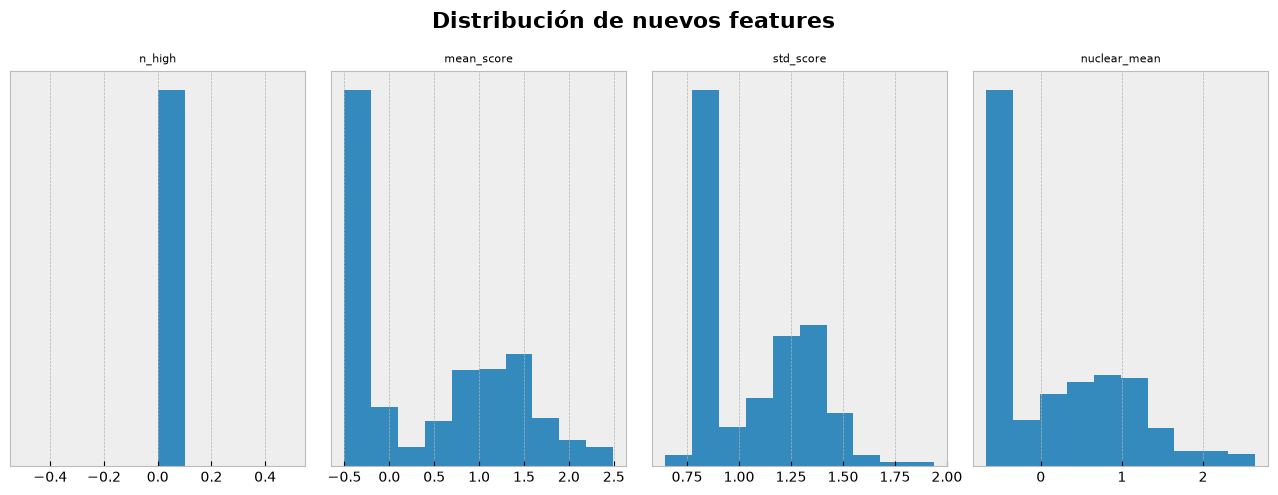

In [53]:
new_cols = ['n_high', 'mean_score', 'std_score', 'nuclear_mean']
fig, axes = plt.subplots(1, 4, figsize=(13, 5))

with plt.style.context('bmh'):
    for ax, col in zip(axes.ravel(), new_cols):
        ax.hist(data_feat[col].astype(float), bins=10)
        ax.set_title(col, fontsize=8)
        ax.set_yticks([])
    
    fig.suptitle("Distribución de nuevos features",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

Aquí, se puede apreciar la distribución de los 4 nuevos atributos.

### Declaración de uso de Inteligencia Artificial Generativa
Para la siguiente práctica, se utlizó Google Gemini para consultas referentes a formato de grágicos de Matplotlib. También se utilizó calude para realizar correciones de código, particularmente para el cálculo de t-SNE y UMAP.